# Importing the dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.preprocessing import (
    TargetEncoder, 
    OneHotEncoder, 
    LabelEncoder
)

# Loading the dataset

In [2]:
main_dset = pd.read_csv("/home/mikkel/Desktop/ai-projects/machine-learning/ug-ransomware/datasets/final(2).csv")
copy_dset = main_dset.copy()

In [3]:
main_x = main_dset.iloc[:, :-1]
main_y = main_dset.iloc[:, -1]

copy_x = copy_dset.iloc[:, :-1]
copy_y = copy_dset.iloc[:, -1]

# Exploring the dataset

### Knowing basic info

In [4]:
main_x.info()

<class 'pandas.DataFrame'>
RangeIndex: 149043 entries, 0 to 149042
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Time           149043 non-null  int64
 1   Protcol        149043 non-null  str  
 2   Flag           149043 non-null  str  
 3   Family         149043 non-null  str  
 4   Clusters       149043 non-null  int64
 5   SeddAddress    149043 non-null  str  
 6   ExpAddress     149043 non-null  str  
 7   BTC            149043 non-null  int64
 8   USD            149043 non-null  int64
 9   Netflow_Bytes  149043 non-null  int64
 10  IPaddress      149043 non-null  str  
 11  Threats        149043 non-null  str  
 12  Port           149043 non-null  int64
dtypes: int64(6), str(7)
memory usage: 14.8 MB


In [5]:
main_x.isna().sum()

Time             0
Protcol          0
Flag             0
Family           0
Clusters         0
SeddAddress      0
ExpAddress       0
BTC              0
USD              0
Netflow_Bytes    0
IPaddress        0
Threats          0
Port             0
dtype: int64

In [6]:
main_x.duplicated().sum()

np.int64(392)

In [7]:
main_x.describe()

,Time,Clusters,BTC,USD,Netflow_Bytes,Port
count,149043.000000,149043.000000,149043.000000,149043.000000,149043.000000,149043.000000
mean,21.466979,2.349295,30.554605,14863.441114,2021.278651,5063.949967
std,15.883598,2.828759,101.447102,26849.434659,2271.420987,2.696011
min,-10.000000,1.000000,1.000000,1.000000,1.000000,5061.000000
25%,8.000000,1.000000,8.000000,512.000000,353.000000,5062.000000
50%,19.000000,1.000000,13.000000,4321.000000,1031.000000,5062.000000
75%,32.000000,2.000000,22.000000,18454.000000,3188.000000,5066.000000
max,96.000000,12.000000,1980.000000,126379.000000,12360.000000,5068.000000


### Visualizing the numerical aspects of the dataset

In [8]:
num_cols = copy_x.select_dtypes("int64")
num_cols

,Time,Clusters,BTC,USD,Netflow_Bytes,Port
0,50,1,1,500,5,5061
1,40,1,1,504,8,5061
2,30,1,1,508,7,5061
3,20,1,1,512,15,5061
4,57,1,1,516,9,5061
...,...,...,...,...,...,...
149038,33,3,1010,1590,3340,5062
149039,33,3,1014,1596,3351,5062
149040,33,3,1018,1602,3362,5062
149041,33,3,1022,1608,3373,5062


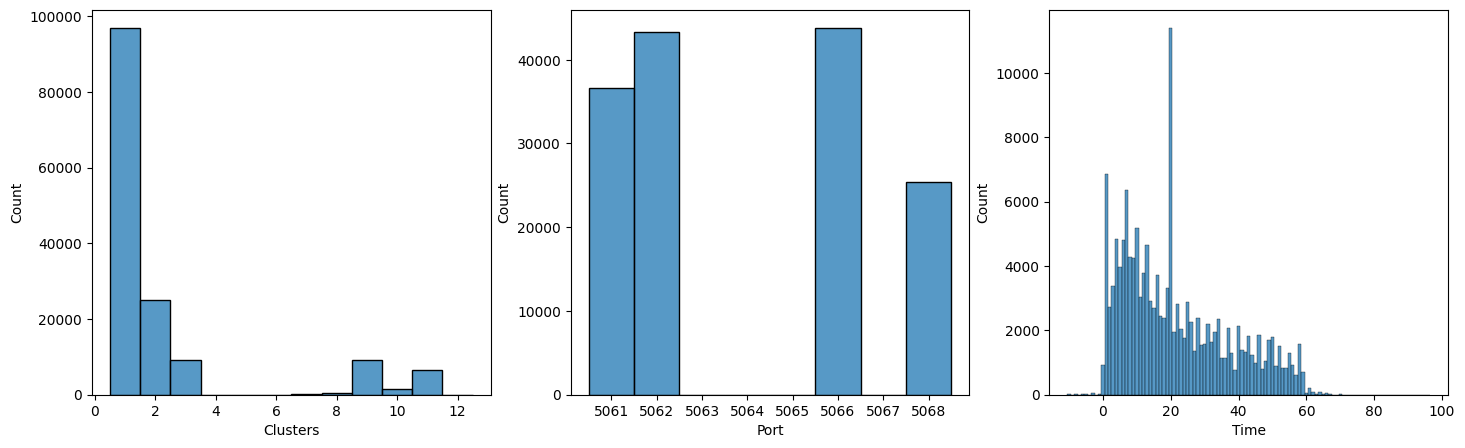

In [9]:
discrete_cols = ["Clusters", "Port", "Time"]
continuous_cols = ["BTC", "USD", "Netflow_Bytes"]

fig, ax = plt.subplots(1, 3, figsize=(17.5, 5))
ax = np.atleast_1d(ax).ravel()

for index, axis in enumerate(ax):
    sns.histplot(copy_x, x=discrete_cols[index], ax=axis, discrete=True)

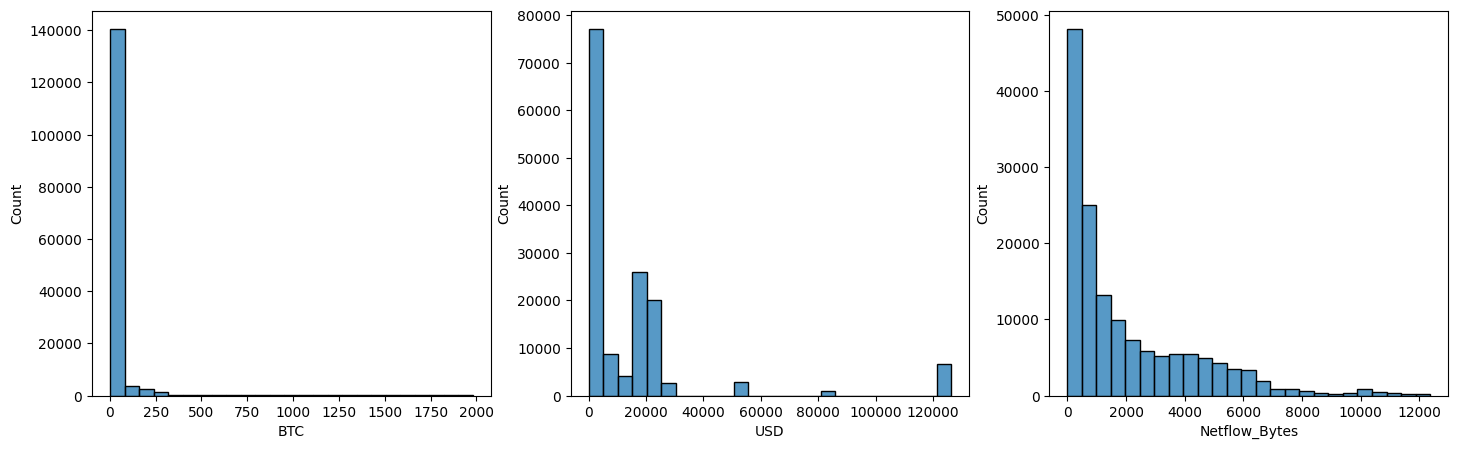

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(17.5, 5))
ax = np.atleast_1d(ax).ravel()

for index, axis in enumerate(ax):
    sns.histplot(copy_x, x=continuous_cols[index], ax=axis, bins=25)

### Visualizing the categorical aspects of the dataset

In [11]:
categorical_types = copy_x.select_dtypes("str")
print(categorical_types)
copy_x = copy_x.drop(["Family", "SeddAddress", "ExpAddress"], axis=1)

       Protcol Flag    Family SeddAddress ExpAddress IPaddress Threats
0          TCP    A  WannaCry    1DA11mPS   1BonuSr7         A   Bonet
1          TCP    A  WannaCry    1DA11mPS   1BonuSr7         A   Bonet
2          TCP    A  WannaCry    1DA11mPS   1BonuSr7         A   Bonet
3          TCP    A  WannaCry    1DA11mPS   1BonuSr7         A   Bonet
4          TCP    A  WannaCry    1DA11mPS   1BonuSr7         A   Bonet
...        ...  ...       ...         ...        ...       ...     ...
149038     UDP   AP  TowerWeb    1AEoiHYZ   1SYSTEMQ         A    Scan
149039     UDP   AP  TowerWeb    1AEoiHYZ   1SYSTEMQ         A    Scan
149040     UDP   AP  TowerWeb    1AEoiHYZ   1SYSTEMQ         A    Scan
149041     UDP   AP  TowerWeb    1AEoiHYZ   1SYSTEMQ         A    Scan
149042     UDP   AP  TowerWeb    1AEoiHYZ   1SYSTEMQ         A    Scan

[149043 rows x 7 columns]


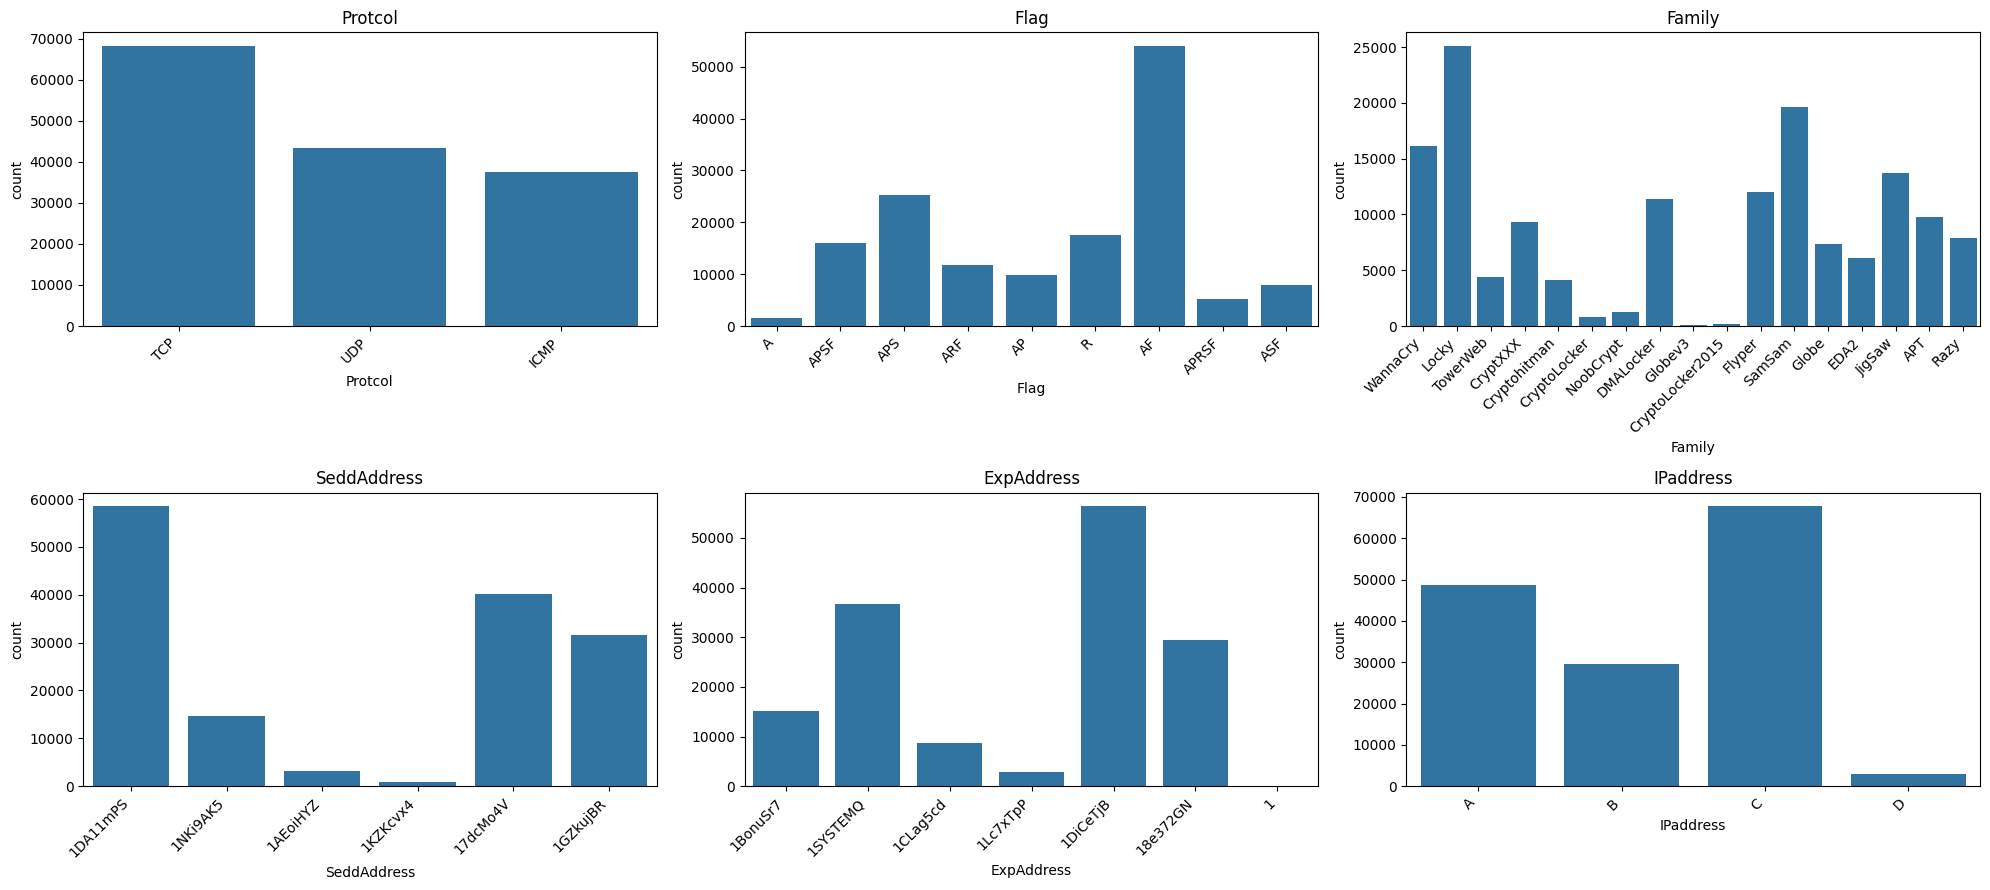

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
axes = np.atleast_1d(axes).ravel()

for i, col in enumerate(categorical_types.columns[:6]):
    sns.countplot(data=categorical_types, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment("right")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

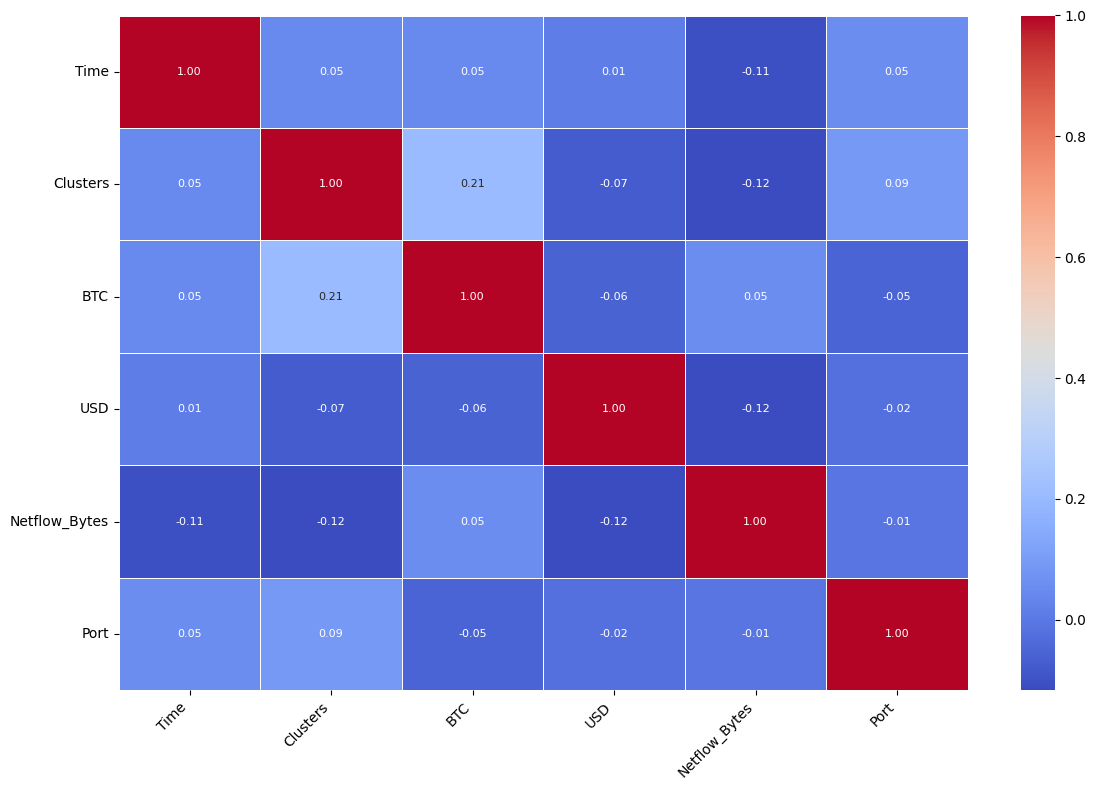

In [13]:
corr_df = pd.concat([copy_x, copy_y.rename("Target")], axis=1)
numeric_corr = corr_df.select_dtypes(include="number").corr()

num_features = numeric_corr.shape[0]
fig_w = max(12, num_features * 0.6)
fig_h = max(8, num_features * 0.5)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=False,
    annot_kws={"size": 8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Visualizing the count of the labels

<Axes: xlabel='count', ylabel='Prediction'>

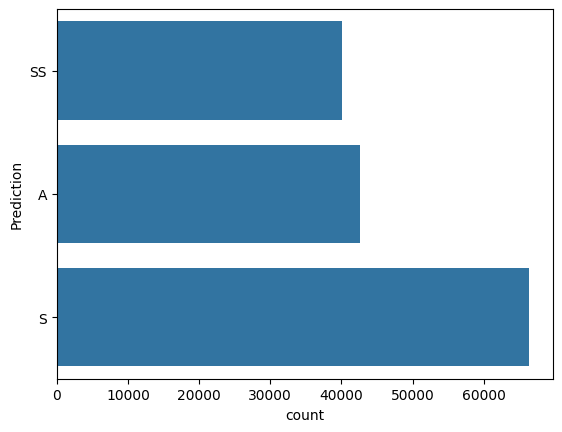

In [4]:
sns.countplot(main_y)

# Preprocessing the main dataset

- Remove Family, Clusters, SeddAddress, ExpAddress BTC, USD, IPaddress, Threats, Ports
- Standardize Time, Netflow_Bytes
- OneHotEncode Protocol
- TargetEncode Flag
- LabelEncode Prediction

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder

### Removing columns

In [6]:
cols_to_remove = [
    "Family",
    "Clusters",
    "SeddAddress",
    "ExpAddress",
    "BTC",
    "USD",
    "IPaddress",
    "Threats",
    "Port"
]

main_x = main_x.drop(cols_to_remove, axis=1)

### Standardizing Time and Netflow_Bytes

In [7]:
scaler = StandardScaler()

main_x[["Time", "Netflow_Bytes"]] = scaler.fit_transform(main_x[["Time", "Netflow_Bytes"]])
main_x

,Time,Protcol,Flag,Netflow_Bytes
0,1.796389,TCP,A,-0.887676
1,1.166806,TCP,A,-0.886355
2,0.537224,TCP,A,-0.886795
3,-0.092358,TCP,A,-0.883273
4,2.237096,TCP,A,-0.885915
...,...,...,...,...
149038,0.726099,UDP,AP,0.580573
149039,0.726099,UDP,AP,0.585416
149040,0.726099,UDP,AP,0.590259
149041,0.726099,UDP,AP,0.595101


### OneHotEncoding the Protcol feature

In [8]:
ohe = OneHotEncoder()

main_x = main_x.rename(columns={"Protcol": "Protocol"})

In [9]:
temp_protocol = ohe.fit_transform(main_x[["Protocol"]])
temp_protocol = pd.DataFrame(temp_protocol.toarray(), columns=ohe.get_feature_names_out())

main_x = pd.concat([
    main_x.drop(["Protocol"], axis=1),
    temp_protocol
],
axis=1
)

In [10]:
main_x

,Time,Flag,Netflow_Bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,1.796389,A,-0.887676,0.0,1.0,0.0
1,1.166806,A,-0.886355,0.0,1.0,0.0
2,0.537224,A,-0.886795,0.0,1.0,0.0
3,-0.092358,A,-0.883273,0.0,1.0,0.0
4,2.237096,A,-0.885915,0.0,1.0,0.0
...,...,...,...,...,...,...
149038,0.726099,AP,0.580573,0.0,0.0,1.0
149039,0.726099,AP,0.585416,0.0,0.0,1.0
149040,0.726099,AP,0.590259,0.0,0.0,1.0
149041,0.726099,AP,0.595101,0.0,0.0,1.0


### TargetEncoding the Flag feature

In [11]:
main_x

,Time,Flag,Netflow_Bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,1.796389,A,-0.887676,0.0,1.0,0.0
1,1.166806,A,-0.886355,0.0,1.0,0.0
2,0.537224,A,-0.886795,0.0,1.0,0.0
3,-0.092358,A,-0.883273,0.0,1.0,0.0
4,2.237096,A,-0.885915,0.0,1.0,0.0
...,...,...,...,...,...,...
149038,0.726099,AP,0.580573,0.0,0.0,1.0
149039,0.726099,AP,0.585416,0.0,0.0,1.0
149040,0.726099,AP,0.590259,0.0,0.0,1.0
149041,0.726099,AP,0.595101,0.0,0.0,1.0


In [12]:
main_x

,Time,Flag,Netflow_Bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,1.796389,A,-0.887676,0.0,1.0,0.0
1,1.166806,A,-0.886355,0.0,1.0,0.0
2,0.537224,A,-0.886795,0.0,1.0,0.0
3,-0.092358,A,-0.883273,0.0,1.0,0.0
4,2.237096,A,-0.885915,0.0,1.0,0.0
...,...,...,...,...,...,...
149038,0.726099,AP,0.580573,0.0,0.0,1.0
149039,0.726099,AP,0.585416,0.0,0.0,1.0
149040,0.726099,AP,0.590259,0.0,0.0,1.0
149041,0.726099,AP,0.595101,0.0,0.0,1.0


In [13]:
t_encoder = TargetEncoder()
temp_flag = t_encoder.fit_transform(main_x[["Flag"]], main_y)
temp_flag = pd.DataFrame(temp_flag, columns=t_encoder.get_feature_names_out())

main_x = pd.concat([
    main_x.drop(["Flag"], axis=1),
    temp_flag
], axis=1)

main_x

,Time,Netflow_Bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP,Flag_A,Flag_S,Flag_SS
0,1.796389,-0.887676,0.0,1.0,0.0,0.058913,0.000000,0.940992
1,1.166806,-0.886355,0.0,1.0,0.0,0.059461,0.000000,0.940439
2,0.537224,-0.886795,0.0,1.0,0.0,0.057709,0.000000,0.942196
3,-0.092358,-0.883273,0.0,1.0,0.0,0.059461,0.000000,0.940439
4,2.237096,-0.885915,0.0,1.0,0.0,0.063928,0.000000,0.935967
...,...,...,...,...,...,...,...,...
149038,0.726099,0.580573,0.0,0.0,1.0,0.247666,0.747506,0.004805
149039,0.726099,0.585416,0.0,0.0,1.0,0.250098,0.744341,0.005536
149040,0.726099,0.590259,0.0,0.0,1.0,0.247578,0.747103,0.005295
149041,0.726099,0.595101,0.0,0.0,1.0,0.247666,0.747506,0.004805


### Oversampling the labels

In [14]:
oversampler = SMOTE(sampling_strategy="minority")
main_x, main_y = oversampler.fit_resample(main_x, main_y)

In [15]:
main_y

0         SS
1         SS
2         SS
3         SS
4         SS
          ..
175316    SS
175317    SS
175318    SS
175319    SS
175320    SS
Name: Prediction, Length: 175321, dtype: str

### LabelEncoding the y target

In [16]:
label_encoder = LabelEncoder()
main_y = label_encoder.fit_transform(main_y)

In [18]:
main_y

array([2, 2, 2, ..., 2, 2, 2], shape=(175321,))

# Training the machine learning models

- DecisionTreeClassifier
- RandomForestClassifier
- Support Vector Classifier
- PyTorch Feed-Forward Network

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)
import torch

### Initializing the test parameters

In [2]:
strat_kfold = StratifiedKFold(shuffle=True, random_state=42)

scoring_dictionary = {
    "accuracy": make_scorer(accuracy_score, average="macro"),
    "precision": make_scorer(precision_score, average="macro"),
    "recall": make_scorer(recall_score, average="macro"),
    "f1": make_scorer(f1_score, average="macro")
}

NameError: name 'StratifiedKFold' is not defined

### Training the DecisionTreeClassifier

In [1]:
tree_parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [depth for depth in range(15, 35, 5)],
    "min_samples_split": [samp_split for samp_split in range(10, 50, 10)],
    "min_samples_leaf": [samp_leaf for samp_leaf in range(6, 30, 6)],
    "random_state": [42]
}

grid_parameters = {
    "estimator": DecisionTreeClassifier(),
    "param_grid": tree_parameter_grid,
    "scoring": scoring_dictionary,
    "n_jobs": -1,
    "refit": "precision",
    "cv": strat_kfold,
    "verbose": 3
}

dt_gs_instance = GridSearchCV(**grid_parameters)
dt_gs_instance.fit(main_x, main_y)

NameError: name 'DecisionTreeClassifier' is not defined